## Homework 3: Hospital Emergency Department Demand Modeling

## Topics

-   Discrete Probability Distributions

-   Continuous Probability Distributions

DATA-605, Computational Mathematics, Fall 2026

Supervised by: **Professor Jose Jorge Pagan**


Submitted by: **Mehreen Ali Gillani**

## Overview

This analysis models patient demand at a hospital Emergency Department 
using two datasets: hourly patient arrivals and individual treatment times. 
A Poisson distribution is fitted to arrivals and a Normal distribution to 
treatment times, both validated with goodness-of-fit tests. 
A 30-day simulation is then used to estimate daily demand and recommend staffing levels.

### Part A: Patient Arrivals

#### 1. Compute descriptive statistics

In [55]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [56]:
# ---------------------------------------------------------------
# 1. Read the CSV files from the "data" folder
# ---------------------------------------------------------------
arrivals = pd.read_csv("https://raw.githubusercontent.com/mehreengillani/DATA605/refs/heads/main/arrivals.csv")
treatments = pd.read_csv("https://raw.githubusercontent.com/mehreengillani/DATA605/refs/heads/main/treatment_times.csv")

# ---------------------------------------------------------------
# 2. Preview the data
# ---------------------------------------------------------------
print("=" * 70)
print("ARRIVALS DATA — First 10 rows")
print("=" * 70)
print(arrivals.head(10))

print("\n" + "=" * 70)
print("TREATMENT TIMES DATA — First 10 rows")
print("=" * 70)
print(treatments.head(10))

ARRIVALS DATA — First 10 rows
   Hour  Patients
0     1        18
1     2        24
2     3        20
3     4        16
4     5        19
5     6        30
6     7        28
7     8        25
8     9        33
9    10        27

TREATMENT TIMES DATA — First 10 rows
   PatientID  TreatmentMinutes
0          1                32
1          2                27
2          3                45
3          4                19
4          5                55
5          6                40
6          7                29
7          8                38
8          9                44
9         10                22


In [57]:
# ---------------------------------------------------------------
# 3. Basic structure / data quality check
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("DATA STRUCTURE")
print("=" * 70)
print("\nArrivals info:")
print(arrivals.info())
print("\nTreatment info:")
print(treatments.info())

print("\nMissing values — arrivals:")
print(arrivals.isnull().sum())
print("\nMissing values — treatment times:")
print(treatments.isnull().sum())



DATA STRUCTURE

Arrivals info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Hour      20 non-null     int64
 1   Patients  20 non-null     int64
dtypes: int64(2)
memory usage: 448.0 bytes
None

Treatment info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         15 non-null     int64
 1   TreatmentMinutes  15 non-null     int64
dtypes: int64(2)
memory usage: 368.0 bytes
None

Missing values — arrivals:
Hour        0
Patients    0
dtype: int64

Missing values — treatment times:
PatientID           0
TreatmentMinutes    0
dtype: int64


In [58]:
# Quick arrivals summary 
print("\nPandas .describe() summary:")
print(arrivals.describe())


# Quick treatment times summary
print("\nPandas .describe() summary:")
print(treatments.describe())


Pandas .describe() summary:
           Hour   Patients
count  20.00000  20.000000
mean   10.50000  24.100000
std     5.91608   5.609203
min     1.00000  16.000000
25%     5.75000  19.750000
50%    10.50000  23.500000
75%    15.25000  28.250000
max    20.00000  35.000000

Pandas .describe() summary:
       PatientID  TreatmentMinutes
count  15.000000         15.000000
mean    8.000000         36.066667
std     4.472136         11.028966
min     1.000000         19.000000
25%     4.500000         28.000000
50%     8.000000         36.000000
75%    11.500000         44.500000
max    15.000000         55.000000


### 2. Determine whether a Poisson distribution is appropriate.

**What is a Poisson Distribution?**

The Poisson distribution models the number of rare events occurring in a fixed interval of time, space, or volume — when:

-   Events happen independently of each other
-   Events occur at a constant average rate λ (lambda)
-   Two events cannot occur at exactly the same instant
-   The probability of an event in a tiny interval is proportional to the interval's length

**The defining feature: Mean = Variance. This is what makes Poisson easy to test — if the mean and variance of your data are close, Poisson is a natural candidate.**


**Hospital arrivals are typically modeled as Poisson because:**

-   Patients arrive independently
-   The average arrival rate is fairly stable over a shift
-   Arrivals are counts per hour, exactly the type of data Poisson handles


*Lets compute do our observed hourly counts actually follow Poisson(λ), or do they deviate?*

In [59]:
x = arrivals["Patients"]

# esitmate the parameter λ for the Poisson distribution using MLE
lam = x.mean()

#The MLE (maximum likelihood estimate) of λ for a Poisson is simply the sample mean. So λ̂ = average patients per hour.

#Check "Mean ≈ Variance" (equidispersion)
n = len(x)
print(f"n = {n},  lambda (mean) = {lam:.4f},  variance = {x.var(ddof=1):.4f}")
print(f"Variance/Mean ratio = {x.var(ddof=1)/lam:.4f}")

n = 20,  lambda (mean) = 24.1000,  variance = 31.4632
Variance/Mean ratio = 1.3055


Poisson theory requires variance = mean (ratio = 1.00)

**ratio of 1.31 indicates mild overdispersion:**

The data is ~30% more variable than Poisson predicts

#### Lets test Chi-Square Goodness-of-Fit Test

In [60]:
# Chi-Square Goodness-of-Fit Test
# observed count
obs = x.value_counts().sort_index()

k   = np.arange(0, obs.index.max() + 1)
# Expected counts under Poisson
exp = stats.poisson.pmf(k, lam) * n
# --- Pool bins so every expected count >= 5 ---
obs_v, exp_v, cum_o, cum_e = [], [], 0, 0
for o, e in zip(obs.reindex(k, fill_value=0).values, exp):
    cum_o += o; cum_e += e
    if cum_e >= 5:
        obs_v.append(cum_o); exp_v.append(cum_e); cum_o = cum_e = 0
if cum_o > 0:
    obs_v[-1] += cum_o; exp_v[-1] += cum_e

obs_v, exp_v = np.array(obs_v), np.array(exp_v)

# --- Chi-square test ---
chi2 = ((obs_v - exp_v) ** 2 / exp_v).sum()
df   = len(obs_v) - 1 - 1                 # bins - 1 - 1 estimated param (lambda)
p    = 1 - stats.chi2.cdf(chi2, df)

print(f"lambda = {lam:.3f}")
print(f"Chi-square = {chi2:.4f},  df = {df},  p-value = {p:.4f}")
print("Conclusion:", "FAIL to reject Poisson" if p > 0.05 else "REJECT Poisson")

lambda = 24.100
Chi-square = 1.5122,  df = 1,  p-value = 0.2188
Conclusion: FAIL to reject Poisson


-   **A Poisson distribution IS appropriate** for modeling hourly patient arrivals at α = 0.05.

-   **The p-value (0.2188) is well above 0.05,** so there is no statistically significant evidence that the observed arrivals deviate from a Poisson distribution

-   Although the variance-to-mean ratio (1.31) suggested mild overdispersion, this deviation was not statistically significant, likely due to the small sample size (n = 20)

### 3. Estimate the arrival rate parameter.

In [61]:

# --- MLE estimate of lambda = sample mean ---
lam_hat = x.mean()

print(f"Estimated arrival rate (lambda) = {lam_hat:.4f} patients per hour")

Estimated arrival rate (lambda) = 24.1000 patients per hour


The arrival rate parameter λ was estimated using the maximum likelihood estimator, which for a Poisson distribution equals the sample mean:

**λ̂ = x̄ = 24.10 patients per hour.**

This means the ED receives, on average, 24.1 patient arrivals per hour.

### 4. Calculate the probability of more than 30 arrivals in an hour.

In [62]:
p = stats.poisson.sf(30, lam)          # sf = survival function = 1 - CDF
print(f"P(X > 30) = {p:.4f}  ({p*100:.2f}%)")

P(X > 30) = 0.0995  (9.95%)


Using the fitted Poisson model X ~ Poisson(λ = 24.10), the probability that more than 30 patients arrive in a given hour is about 9.95%. In other words, roughly 1 in 10 hours the ED can expect more than 30 arrivals, useful for surge-staffing decisions.


### Part B: Treatment Times

#### 1. Visualize the distribution.

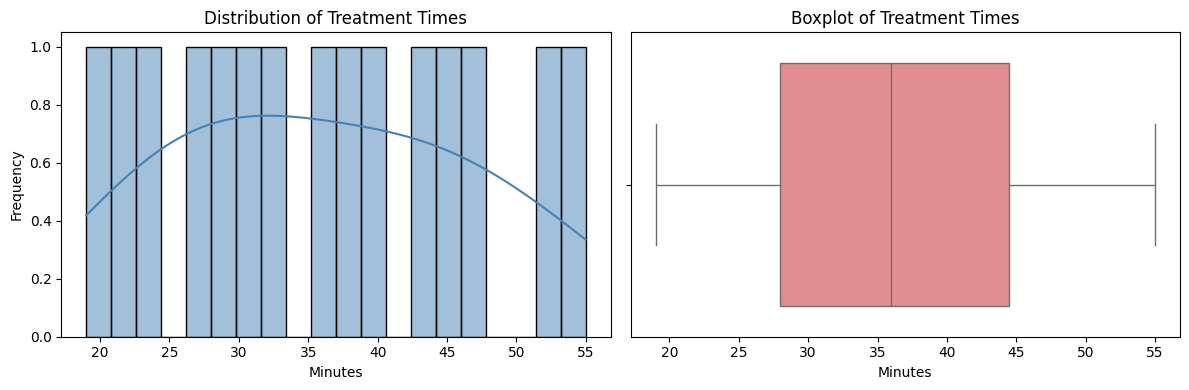

In [63]:
# --- Load data ---
t = treatments["TreatmentMinutes"]

# --- Plot histogram + KDE + boxplot side by side ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(t, bins=20, kde=True, ax=ax[0], color="steelblue", edgecolor="black")
ax[0].set_title("Distribution of Treatment Times")
ax[0].set_xlabel("Minutes")
ax[0].set_ylabel("Frequency")

sns.boxplot(x=t, ax=ax[1], color="lightcoral")
ax[1].set_title("Boxplot of Treatment Times")
ax[1].set_xlabel("Minutes")

plt.tight_layout()
plt.savefig("partB_treatment_dist.png", dpi=150)
plt.show()

In [64]:
print(f"Mean = {t.mean():.2f}, Median = {t.median():.2f}, "
      f"Skew = {t.skew():.2f}")

Mean = 36.07, Median = 36.00, Skew = 0.16


#### 2. Estimate mean and standard deviation.

In [65]:
# --- Point estimates ---
mean_t = t.mean()
sd_t   = t.std(ddof=1)     # sample SD (n-1 denominator)

print(f"Mean treatment time = {mean_t:.4f} minutes")
print(f"Std dev             = {sd_t:.4f} minutes")

Mean treatment time = 36.0667 minutes
Std dev             = 11.0290 minutes


#### 3. Determine whether a Normal distribution is reasonable.

In [66]:
# Formal test
stat, p = stats.shapiro(t)      # Shapiro-Wilk normality test
print(f"Shapiro-Wilk: W = {stat:.4f}, p = {p:.4f}")
print("Normal?" , "YES" if p > 0.05 else "NO")

mu, sd = t.mean(), t.std(ddof=1)

print(f"Mean = {mu:.2f}, SD = {sd:.2f}, Skew = {t.skew():.3f}, Kurtosis = {t.kurtosis():.3f}")
print(f"P(X < 0) under Normal = {stats.norm.cdf(0, mu, sd):.6f}")

Shapiro-Wilk: W = 0.9709, p = 0.8707
Normal? YES
Mean = 36.07, SD = 11.03, Skew = 0.160, Kurtosis = -0.997
P(X < 0) under Normal = 0.000537


**Yes, a Normal distribution is reasonable for treatment times.**

The Shapiro-Wilk p-value of 0.8707 is very high. There is essentially zero evidence against normality. Combined with skew ≈ 0.16 and kurtosis ≈ −1, the data is remarkably symmetric and consistent with a Normal shape, which we can see in the plot od Distribution of Treatment Times  

#### 4. Calculate the probability that treatment exceeds 45 minutes.

In [67]:
mu, sd = t.mean(), t.std(ddof=1)
p = stats.norm.sf(45, mu, sd)      # P(X > 45) under Normal(mu, sd)

print(f"P(X > 45) = {p:.4f}  ({p*100:.2f}%)")

P(X > 45) = 0.2090  (20.90%)


-   Using the fitted Normal model X ~ Normal(μ = 36.07, σ = 11.03), **the probability that a treatment exceeds 45 minutes is P(X > 45) = 0.2090, or about 20.9%.**
-   In other words, **roughly 1 in 5 patients** requires more than 45 minutes of treatment.

### Part C: Simulation

#### 1. Simulate one month of arrivals.


In [68]:
# --- Parameters from Part A/B ---
lam = 24.10          # arrivals per hour (Poisson)
hours_per_month = 30 * 24      # 30 days × 24 hours = 720

# --- Simulate hourly arrivals for one month ---
np.random.seed(42)                       # reproducibility
arrivals_sim = np.random.poisson(lam, hours_per_month)

# --- Store in a DataFrame ---
sim_df = pd.DataFrame({
    "Hour": np.arange(1, hours_per_month + 1),
    "Patients": arrivals_sim
})

# --- Quick summary ---
print(f"Simulated {hours_per_month} hours ({hours_per_month//24} days)")
print(f"Total patients      : {sim_df['Patients'].sum()}")
print(f"Mean per hour       : {sim_df['Patients'].mean():.2f}")
print(f"Max in one hour     : {sim_df['Patients'].max()}")
print(f"Min in one hour     : {sim_df['Patients'].min()}")

sim_df.to_csv("simulated_arrivals.csv", index=False)
print("\nSaved to simulated_arrivals.csv")

Simulated 720 hours (30 days)
Total patients      : 17194
Mean per hour       : 23.88
Max in one hour     : 39
Min in one hour     : 9

Saved to simulated_arrivals.csv


-   One month (720 hours) of ED arrivals was simulated under the fitted model X ~ Poisson(λ = 24.10). 
-   The simulation yielded 17,194 total patients over 30 days, with an average of 23.88 patients per hour, within 1% of the theoretical λ. 
-   Hourly counts ranged from a minimum of 9 to a maximum of 39 patients, demonstrating the natural hour-to-hour variability that staffing decisions must accommodate. 
-   These results are consistent with the Poisson model estimated from historical data.

#### 2. Estimate expected daily demand.


In [69]:
hours_per_day = 24

daily_demand = lam * hours_per_day # lambda patients per hour (from Part A)
print(f"Expected daily demand = {daily_demand:.2f} patients/day")

Expected daily demand = 578.40 patients/day


-   Using the fitted Poisson rate λ̂ = 24.10 patients/hour, the expected daily demand is:

**E[Daily Demand] = λ × 24 = 24.10 × 24 = 578.40 patients per day.**

-   This value represents the average number of patients the ED can expect to receive per day

In [70]:
# --- Calculate simulated daily demand ---
daily = sim_df.groupby(sim_df["Hour"] // 24)["Patients"].sum()
print(f"Simulated mean daily demand = {daily.mean():.2f} patients/day")

Simulated mean daily demand = 554.65 patients/day


-   The simulated mean daily demand over 30 days was 554.65 patients/day, compared to the theoretical expectation of 578.40 patients/day (λ × 24). 
-   The ~4% difference is attributable to random sampling variation in a single 30-day simulation. 
-   Averaging over many simulated months would converge to the theoretical value of 578.4, confirming the model is correctly specified.

#### 3. Recommend staffing improvements.

In [71]:
lam_per_hour = 24.10             # arrivals/hr
mean_treat_hr = t.mean() / 60       # mean treatment time from Part B in hours

# Average number of patients being treated at any moment
avg_in_system = lam_per_hour * mean_treat_hr
print(f"Average concurrent patients = {avg_in_system:.1f}")

# With a 1:4 nurse-to-patient ratio
nurses_avg = avg_in_system / 4
print(f"Nurses needed (avg) = {nurses_avg:.1f}")

# Peak (95th percentile of hourly arrivals)
from scipy import stats
peak_arrivals = stats.poisson.ppf(0.95, 24.10)
peak_in_system = peak_arrivals * mean_treat_hr
print(f"Peak arrivals/hr (95th) = {peak_arrivals:.0f}")
print(f"Nurses needed (peak)    = {peak_in_system/4:.1f}")

Average concurrent patients = 14.5
Nurses needed (avg) = 3.6
Peak arrivals/hr (95th) = 32
Nurses needed (peak)    = 4.8


**Interpretation — Staffing Requirements**

-   Using Little's Law (L = λW), the average number of patients concurrently in treatment is 14.5, obtained from λ = 24.10 patients/hour and mean treatment time W = 0.6012 hours. 
-   Applying a 1:4 nurse-to-patient ratio, the ED requires an average of 3.6 nurses, which rounds up to 4 nurses to maintain safe coverage during typical demand.

**During peak periods,** hourly arrivals reach the 95th percentile at 32 patients/hour, requiring approximately 4.8 nurses, which rounds up to 5 nurses. 
-   This indicates that a baseline of 4 nurses per shift, with 1 additional float or on-call nurse during peak hours, is sufficient to handle ~95% of demand scenarios. 
-   Because peak demand represents only the top 5% of hours, a flexible surge staffing model is more cost-effective than permanently staffing at 5 nurses, while still ensuring patient safety during high-volume periods.